In [ ]:
from transformers.modeling_outputs import SequenceClassifierOutput
import torch
import torch.nn as nn
from datasets import Dataset
from transformers import (
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    AutoModelForSequenceClassification,
    AutoConfig,
    AutoTokenizer
)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from peft import LoraConfig, get_peft_model
from rdkit import Chem
import warnings
warnings.filterwarnings('ignore')

def remove_unconvertable_smiles(df):
    """変換できないSMILESを削除"""
    df['mol'] = df['smiles'].apply(lambda x: Chem.MolFromSmiles(x))
    invalid_smiles = df[df['mol'].isna()]['smiles'].tolist()
    if invalid_smiles:
        print(f"⚠️ 無効なSMILES {len(invalid_smiles)} 件を削除しました")
    df_new = df[df['mol'].notna()]
    df_new = df_new.reset_index(drop=True)
    df_new = df_new.drop(columns=['mol'])
    return df_new

class RegressionModel(nn.Module):
    """
    回帰タスク用のカスタムモデル

    - 出力層が制限されていない（分類用ヘッドではなく、線形層を使用）
    - Tb値の実際の範囲に対応
    - MSE損失で直接回帰を実現
    """
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model.base_model
        self.dropout = nn.Dropout(0.1)
        hidden_size = base_model.config.hidden_size
        self.regression_head = nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True
        )

        cls_output = outputs.hidden_states[-1][:, 0, :]
        cls_output = self.dropout(cls_output)

        logits = self.regression_head(cls_output).squeeze(-1)

        loss = None
        if labels is not None:
            loss_fn = nn.MSELoss()
            loss = loss_fn(logits, labels.float())

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits.unsqueeze(-1) if loss is None else logits.unsqueeze(-1)
        )

def prepare_datasets(df, test_size=0.2, valid_size=0.1, random_state=42):
    """データセットを分割する関数"""
    train_indices = np.arange(len(df))
    train_idx, test_idx = train_test_split(
        train_indices,
        test_size=test_size,
        random_state=random_state
    )

    df_train = df.iloc[train_idx].reset_index(drop=True)
    df_test = df.iloc[test_idx].reset_index(drop=True)

    train_indices_2 = np.arange(len(df_train))
    train_train_idx, train_valid_idx = train_test_split(
        train_indices_2,
        test_size=valid_size,
        random_state=random_state
    )

    df_train_train = df_train.iloc[train_train_idx].reset_index(drop=True)
    df_train_valid = df_train.iloc[train_valid_idx].reset_index(drop=True)

    print(f"訓練セット: {len(df_train_train)}")
    print(f"検証セット: {len(df_train_valid)}")
    print(f"テストセット: {len(df_test)}")

    return df_train_train, df_train_valid, df_test

class RegressionTrainer(Trainer):
    """回帰タスク用のカスタムTrainer"""
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits.squeeze(-1)

        # MSE損失を計算
        loss_fn = nn.MSELoss()
        loss = loss_fn(logits, labels.float())

        return (loss, outputs) if return_outputs else loss

def compute_metrics(eval_pred):
    """回帰タスク用のメトリクス計算"""
    predictions, labels = eval_pred
    predictions = predictions.squeeze()

    valid_mask = ~(np.isnan(predictions) | np.isnan(labels))
    predictions = predictions[valid_mask]
    labels = labels[valid_mask]

    if len(predictions) == 0:
        return {"mse": 0, "rmse": 0, "mae": 0, "r2": 0}

    mse = mean_squared_error(labels, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(labels, predictions)

    try:
        r2 = r2_score(labels, predictions)
    except:
        r2 = 0.0

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }

def tokenize_function(examples, tokenizer, max_length=100):
    """SMILES文字列をトークン化"""
    inputs = tokenizer(
        examples["smiles"],
        truncation=True,
        padding='max_length',
        max_length=max_length
    )
    inputs["labels"] = [float(tb_value) for tb_value in examples["Tb"]]
    return inputs

def train_regression_model(
    df,
    model_name="DeepChem/ChemBERTa-100M-MLM",
    output_dir="./output",
    num_epochs=20,
    batch_size=32,
    learning_rate=1e-4,
    max_length=100,
    random_state=42,
    use_scaler=True
):

    print("="*60)
    print("1. データセット準備")
    print("="*60)
    df_train_train, df_train_valid, df_test = prepare_datasets(
        df,
        test_size=0.2,
        valid_size=0.1,
        random_state=random_state
    )

    print("\n" + "="*60)
    print("2. データ正規化")
    print("="*60)

    scaler = None
    if use_scaler:
        scaler = StandardScaler()
        df_train_train['Tb_normalized'] = scaler.fit_transform(df_train_train[['Tb']])
        df_train_valid['Tb_normalized'] = scaler.transform(df_train_valid[['Tb']])
        df_test['Tb_normalized'] = scaler.transform(df_test[['Tb']])

        df_train_train['Tb_for_training'] = df_train_train['Tb_normalized']
        df_train_valid['Tb_for_training'] = df_train_valid['Tb_normalized']
        df_test['Tb_for_training'] = df_test['Tb_normalized']

        print("✓ データを正規化しました")
        print(f"  元のTb範囲: {df['Tb'].min():.2f} - {df['Tb'].max():.2f}")
        print(f"  正規化後: {df_train_train['Tb_normalized'].min():.2f} - {df_train_train['Tb_normalized'].max():.2f}")
    else:
        df_train_train['Tb_for_training'] = df_train_train['Tb']
        df_train_valid['Tb_for_training'] = df_train_valid['Tb']
        df_test['Tb_for_training'] = df_test['Tb']

    print("\n" + "="*60)
    print("3. モデルの読み込み")
    print("="*60)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    config = AutoConfig.from_pretrained(model_name)

    base_model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=1,
    )

    model = RegressionModel(base_model)

    print("\n" + "="*60)
    print("4. LoRA設定")
    print("="*60)
    peft_config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=["query", "value", "dense"],
        lora_dropout=0.1,
        bias="none",
    )
    model = get_peft_model(model, peft_config)
    model.print_trainable_parameters()

    print("\n" + "="*60)
    print("5. データセットのトークン化")
    print("="*60)

    train_dataset = Dataset.from_pandas(df_train_train[['smiles', 'Tb_for_training']].rename(columns={'Tb_for_training': 'Tb'}))
    valid_dataset = Dataset.from_pandas(df_train_valid[['smiles', 'Tb_for_training']].rename(columns={'Tb_for_training': 'Tb'}))
    test_dataset = Dataset.from_pandas(df_test[['smiles', 'Tb_for_training']].rename(columns={'Tb_for_training': 'Tb'}))

    tokenize_fn = lambda examples: tokenize_function(examples, tokenizer, max_length)

    tokenized_train_dataset = train_dataset.map(tokenize_fn, batched=True, remove_columns=["smiles", "Tb"])
    tokenized_valid_dataset = valid_dataset.map(tokenize_fn, batched=True, remove_columns=["smiles", "Tb"])

    print("\n" + "="*60)
    print("6. トレーニング設定")
    print("="*60)

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        learning_rate=learning_rate,
        weight_decay=0.01,
        warmup_steps=500,
        logging_steps=50,
        eval_strategy="steps",
        eval_steps=50,
        save_strategy="steps",
        save_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="eval_mse",
        bf16=True,
        seed=random_state,
        report_to=[],
        greater_is_better=False,
        logging_first_step=True,
    )

    print("\n" + "="*60)
    print("7. トレーニング開始")
    print("="*60)

    trainer = RegressionTrainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train_dataset,
        eval_dataset=tokenized_valid_dataset,
        compute_metrics=compute_metrics,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=5,
                early_stopping_threshold=0.001
            )
        ],
    )

    train_result = trainer.train()
    trainer.save_model(output_dir)

    print("\n" + "="*60)
    print("トレーニング完了")
    print("="*60)

    return model, tokenizer, test_dataset, trainer, train_result, df_train_train, df_test, scaler

def evaluate_model(model, tokenizer, test_dataset, scaler=None, max_length=100):
    device = next(model.parameters()).device
    model.eval()

    predictions = []
    true_values = test_dataset["Tb"]

    print("\n" + "="*60)
    print("テストセット評価中...")
    print("="*60)

    for i, smiles in enumerate(test_dataset["smiles"]):
        if i % 100 == 0:
            print(f"処理中: {i}/{len(test_dataset)}")

        inputs = tokenizer(
            smiles,
            return_tensors="pt",
            padding='max_length',
            truncation=True,
            max_length=max_length
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        predicted_property = outputs.logits.squeeze().item()
        predictions.append(predicted_property)

    predictions = np.array(predictions)
    true_values = np.array(true_values)

    if scaler is not None:
        predictions = scaler.inverse_transform(predictions.reshape(-1, 1)).squeeze()
        true_values = scaler.inverse_transform(true_values.reshape(-1, 1)).squeeze()

    mse = mean_squared_error(true_values, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true_values, predictions)
    r2 = r2_score(true_values, predictions)

    print("\n" + "="*60)
    print("テストセット評価結果")
    print("="*60)
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")
    print("="*60)

    return predictions, true_values

def plot_results(train_dataset, test_dataset, train_predictions, test_predictions):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 8))
    plt.scatter(train_dataset["Tb"], train_predictions, color='red', alpha=0.5, label='Train', s=20)
    plt.scatter(test_dataset["Tb"], test_predictions, color='blue', alpha=0.5, label='Test', s=20)

    all_values = np.concatenate([train_dataset["Tb"], test_dataset["Tb"]])
    min_val = all_values.min()
    max_val = all_values.max()
    plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2)

    plt.xlabel('True. Tb', fontsize=14)
    plt.ylabel('Pred. Tb', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('prediction.png', dpi=100)
    print("\n予測結果を 'prediction.png' に保存しました")
    plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd /content/drive/MyDrive/MI_Autumn_Exp/ML

/content/drive/MyDrive/MI_Autumn_Exp/ML


In [ ]:
df = pd.read_csv(f'data/smiles/Tb_with_smiles_large.csv')

In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 13.8 MB/s eta 0:00:00


In [ ]:
from rdkit import Chem

In [ ]:
def remove_unconvertable_smiles(df):
    df['mol'] = df['smiles'].apply(lambda x: Chem.MolFromSmiles(x))

    # MolがNone（変換失敗）の行のsmilesを表示してその行を削除
    print(df[df['mol'].isna()]['smiles'] + ' cannot be converted into a molecular object')
    df_new = df[df['mol'].notna()]

    df_new = df_new.reset_index(drop=True)
    df_new = df_new.drop(columns=['mol'])
    return df_new
df  = remove_unconvertable_smiles(df)

1. データセット準備
訓練セット: 3613
検証セット: 402
テストセット: 1004

2. データ正規化
✓ データを正規化しました
  元のTb範囲: 194.75 - 735.15
  正規化後: -3.25 - 3.29

3. モデルの読み込み


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MTR and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



4. LoRA設定
trainable params: 192,000 || all params: 3,471,985 || trainable%: 5.5300

5. データセットのトークン化


Map:   0%|          | 0/3613 [00:00<?, ? examples/s]

Map:   0%|          | 0/402 [00:00<?, ? examples/s]


6. トレーニング設定（優先度3の修正）

7. トレーニング開始


Step,Training Loss,Validation Loss,Mse,Rmse,Mae,R2
50,1.052300,1.048337,1.048337,1.023883,0.837475,-0.047063
100,0.994000,1.032904,1.032904,1.016319,0.831150,-0.031649
150,0.981800,0.983493,0.983493,0.991712,0.810126,0.017703
200,0.903600,0.839298,0.839298,0.916132,0.743218,0.161722
250,0.707600,0.549482,0.549482,0.741271,0.563358,0.451186
300,0.490500,0.341356,0.341356,0.584256,0.450744,0.659059
350,0.340300,0.243228,0.243228,0.493182,0.375608,0.757067
400,0.279200,0.194600,0.194600,0.441134,0.332022,0.805637
450,0.254300,0.159631,0.159631,0.399539,0.286336,0.840563
500,0.208900,0.140647,0.140647,0.375029,0.266389,0.859524



トレーニング完了

訓練データの予測を生成中...
処理中: 0/3613
処理中: 500/3613
処理中: 1000/3613
処理中: 1500/3613
処理中: 2000/3613
処理中: 2500/3613
処理中: 3000/3613
処理中: 3500/3613

テストセット評価中...
処理中: 0/1004
処理中: 100/1004
処理中: 200/1004
処理中: 300/1004
処理中: 400/1004
処理中: 500/1004
処理中: 600/1004
処理中: 700/1004
処理中: 800/1004
処理中: 900/1004
処理中: 1000/1004

テストセット評価結果
MSE:  686.1376
RMSE: 26.1942
MAE:  17.8793
R²:   0.9046

ステップ11: 予測結果を可視化中...

予測結果を 'prediction.png' に保存しました


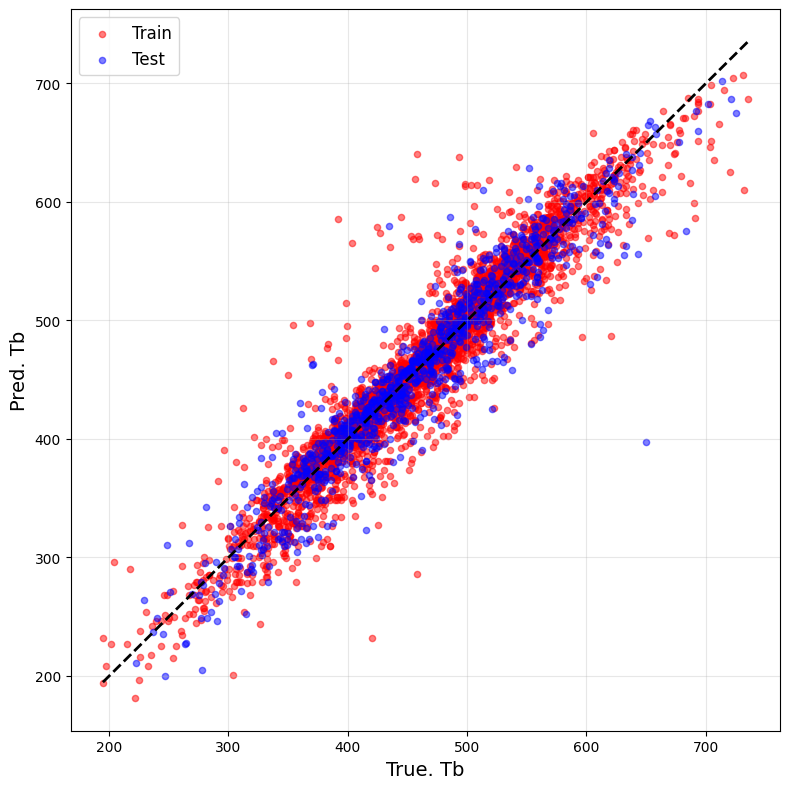


✓ トレーニング完了


In [ ]:
model, tokenizer, test_dataset, trainer, train_result, df_train_train, df_test, scaler = train_regression_model(
        df,
        num_epochs=20,
        batch_size=32,
        learning_rate=1e-4,
        use_scaler=True,
    )

# 訓練データの予測
print("\n訓練データの予測を生成中...")
train_predictions = []
for i, smiles in enumerate(df_train_train["smiles"]):
    if i % 500 == 0:
        print(f"処理中: {i}/{len(df_train_train)}")
    inputs = tokenizer(smiles, return_tensors="pt", padding='max_length', truncation=True, max_length=100)
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    train_predictions.append(outputs.logits.squeeze().item())

# 正規化を逆変換
if scaler is not None:
    train_predictions = scaler.inverse_transform(np.array(train_predictions).reshape(-1, 1)).squeeze()

# テストセットの評価
test_predictions, test_true = evaluate_model(model, tokenizer, test_dataset, scaler=scaler)

# ステップ11: 予測結果の可視化
print("\n" + "="*60)
print("ステップ11: 予測結果を可視化中...")
print("="*60)
plot_results(df_train_train, df_test, train_predictions, test_predictions)

print("\n✓ トレーニング完了")